In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [48]:
def plot_phonons(phonon_bands: str, title: str="Phonon Bands", label='ALAMODE'):
    # Load data
    try: 
        data = np.loadtxt(phonon_bands)
    except IOError:
        print(f"File '{phonon_bands}' not found.")
        exit()
    
    output_text: list[str] = Path(phonon_bands).read_text().split('\n')
    get_k_ticks = lambda x : np.array( x[1].split(' ')[1:], dtype=float )
    
    k_ticks = get_k_ticks(output_text)
    k_labels = ['Γ', 'K', 'M', 'Γ', 'A']

    k_values = data[:, 0]
    freqs_cm = data[:, 1:] 
    cm_to_thz = 1.0 / 33.35641
    freqs_THz = freqs_cm * cm_to_thz

    # Plotting
    fig, ax = plt.subplots(dpi=300)
    plt.figure(figsize=(8, 6))

    num_bands = freqs_THz.shape[1]

    # bands
    for i in range(num_bands):
        if i == (num_bands - 1):
            ax.plot(k_values, freqs_THz[:, i], '-k', label=label)
        else:
            ax.plot(k_values, freqs_THz[:, i], '-k')
        
    ax.set_title(title)
    ax.set_xlabel('High-Symmetry Path')
    ax.set_ylabel('Frequency (THz)')

    ax.set_xticks(k_ticks, k_labels, fontsize=12)
    ax.set_xlim(min(k_ticks), max(k_ticks))
    ax.set_ylim(-0.5, 18)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Vertical Lines at High-Symmetry points
    for tick in k_ticks:
        ax.axvline(x=tick, color='grey', linestyle='-', linewidth=0.5)

    #plt.savefig('ZnO_phonons_corrected.png', dpi=300)
    plt.tight_layout()

    return fig, ax
    

In [53]:
def get_phonon_data(phonon_bands):
    # Load data
    try: 
        data = np.loadtxt(phonon_bands)
    except IOError:
        print(f"File '{phonon_bands}' not found.")
        exit()
    
    output_text: list[str] = Path(phonon_bands).read_text().split('\n')
    get_k_ticks = lambda x : np.array( x[1].split(' ')[1:], dtype=float )
    
    k_ticks = get_k_ticks(output_text)
    k_labels = ['Γ', 'K', 'M', 'Γ', 'A']

    k_values = data[:, 0]
    freqs_cm = data[:, 1:] 
    cm_to_thz = 1.0 / 33.35641
    freqs_THz = freqs_cm * cm_to_thz

    return k_values, freqs_THz


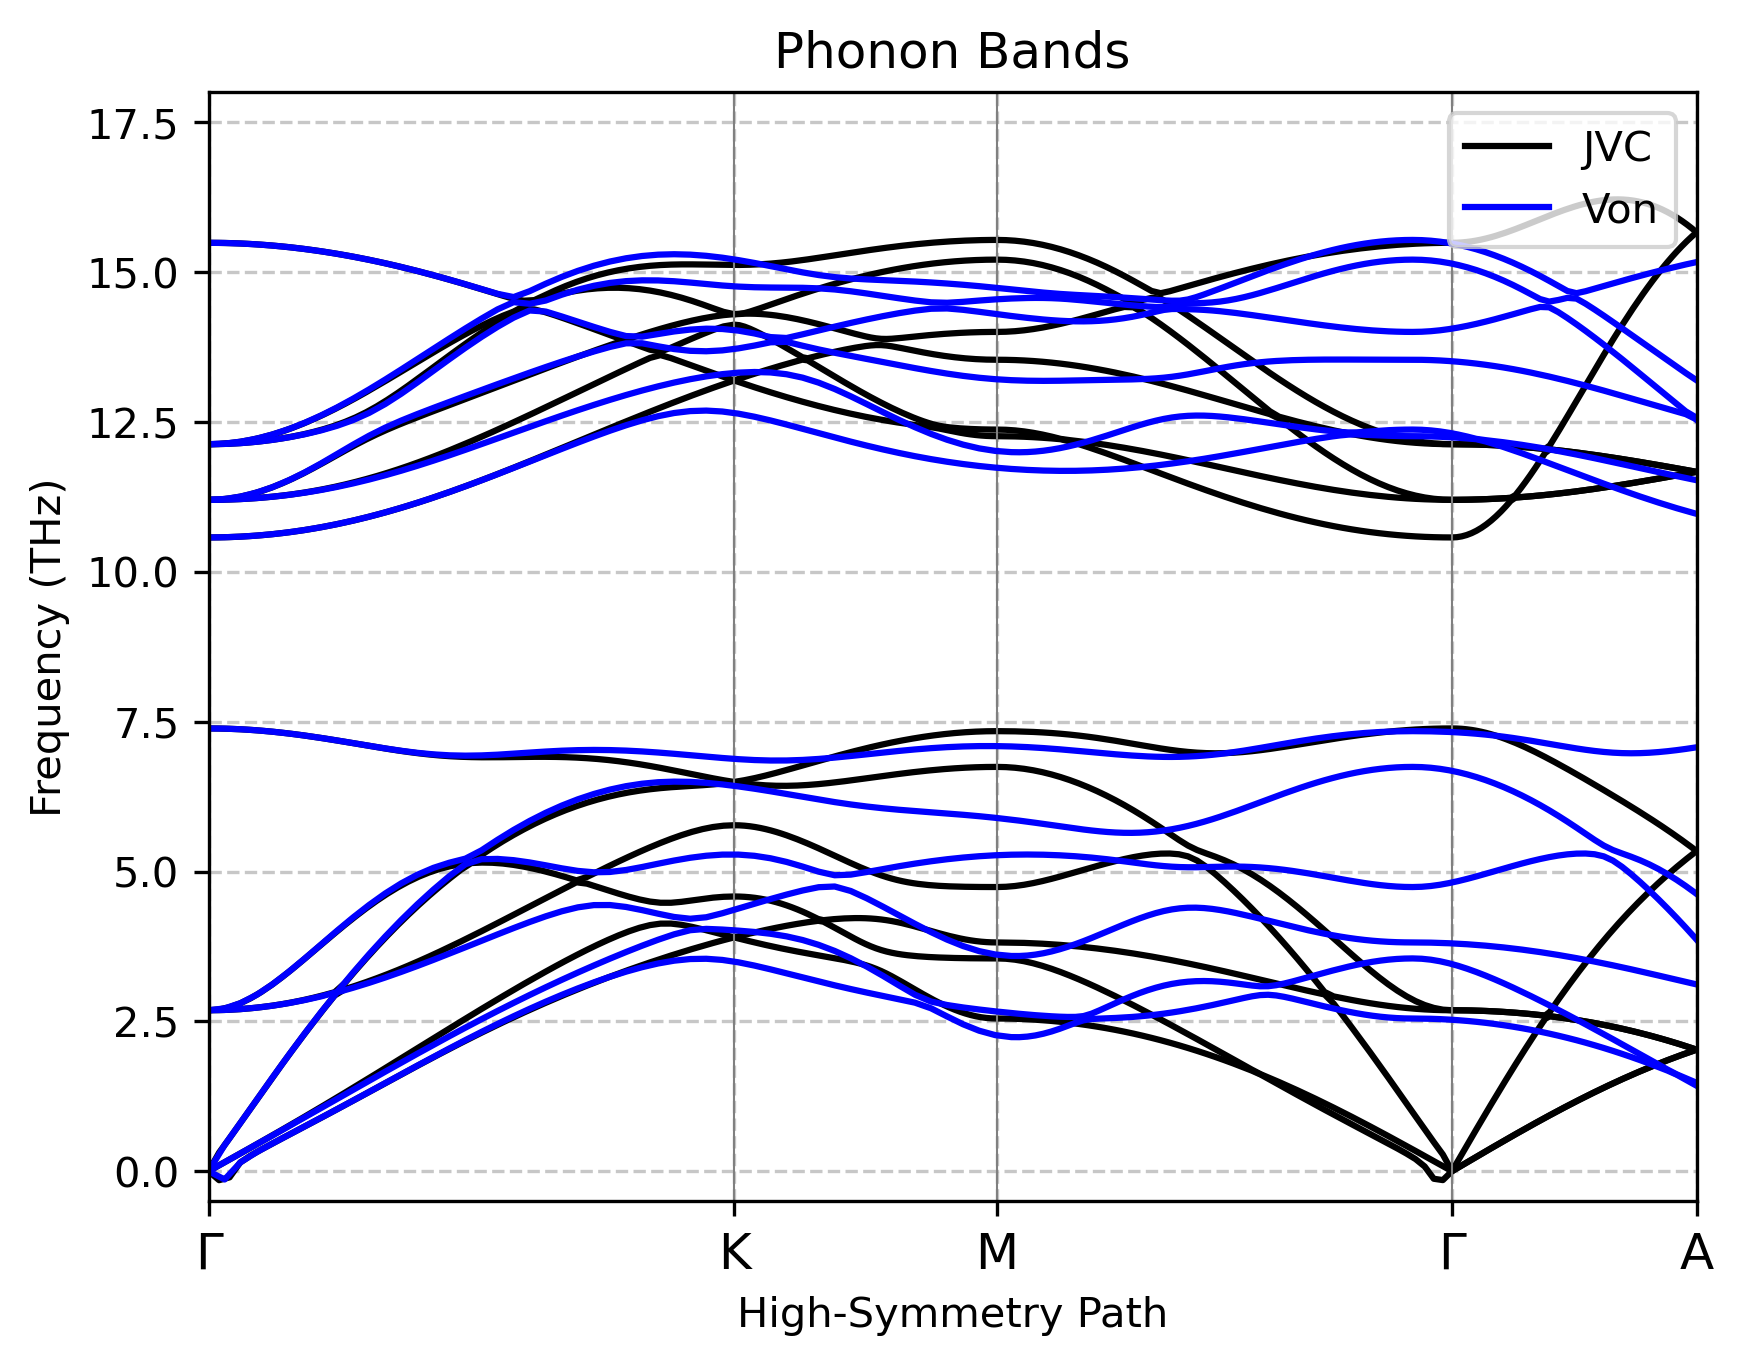

<Figure size 800x600 with 0 Axes>

In [61]:
fig, ax = plot_phonons(phonon_bands='run02/ZnO222.bands', label="JVC")
ks_von, freqs_von = get_phonon_data('ZnO222.bands')

# bands
num_bands = freqs_von.shape[1]
for i in range(num_bands):
    if i == ( num_bands - 1):
        ax.plot(ks_von, freqs_von[:, i], '-b', label='Von')
    else:
        ax.plot(ks_von, freqs_von[:, i], '-b')

ax.legend(loc='upper right')        


## Experimental Data 

Experimental Data Extracted from Ref:

> _"Wu, X. et al. Thermal Conductivity of Wurtzite Zinc-Oxide from First-Principles Lattice Dynamics - a Comparative Study with Gallium Nitride. Sci. Rep. 6, 22504; doi: 10.1038/srep22504 (2016)."_
 
 which uses experimental data from:

> 54. Serrano, J. et al. Phonon dispersion relations of zinc oxide: Inelastic neutron scattering and\textitab initio calculations. Phys.Rev.B 81, 174304 (2010).
> 55. Hewat, A. W. Lattice dynamics of ZnO and BeO. Solid State Commun. 8, 187–189 (1970).
> 56. Thoma, K., Dorner, B., Duesing, G. & Wegener, W. Lattice dynamics of ZnO. Solid State Commun. 15, 1111–1114 (1974).
> 57. Serrano, J. et al. Dependence of phonon widths on pressure and isotopic mass: ZnO. Phys status solidi (b) 235, 260–266 (2003).

In [62]:
# Loading Experimental Data
exp_data_red = pd.read_csv('./ExpDataRefs/ZnO_Phonons_Ref_RedTriangles.txt', sep=';', header=2)
exp_data_purple = pd.read_csv('./ExpDataRefs/ZnO_Phonons_Ref_PurpleCircles.txt', sep=';', header=2)
exp_data_blue = pd.read_csv('./ExpDataRefs/ZnO_Phonons_Ref_BlueSquares.txt', sep=';', header=2)

In [66]:
k_distance, eigenvalues_thz = get_phonon_data('./run02/ZnO222.bands')
k_ticks = [0.000000, 0.677895, 1.016842, 1.603975 ,1.919521]
k_labels = ['Γ', 'K', 'M', 'Γ', 'A']
fig, ax = plt.subplots(figsize=(8, 6), dpi=1200)

num_bands = eigenvalues_thz.shape[1]
# ERROR ~ 0.8 Thz

# uma linha uma banda
for i in range(num_bands):
    
    if i == num_bands-1:
        ax.plot(k_distance, eigenvalues_thz[:, i], '-k', label='ALAMODE')
    else:
        ax.plot(k_distance, eigenvalues_thz[:, i], '-k')

ax.set_title('ZnO Phonon Dispersion')
ax.set_xlabel('High-Symmetry Path')
ax.set_ylabel('Frequency (THz)')

ax.set_xticks(k_ticks, k_labels, fontsize=12)
ax.set_xlim(k_ticks[0], k_ticks[-1])

ax.set_ylim(-1, 18)

ax.grid(True, linestyle='--', alpha=0.7)

for tick in k_ticks:
    ax.axvline(x=tick, color='grey', linestyle='-', linewidth=0.5)

# Experimental Data
ax.scatter(
    x=exp_data_red['k'],
    y=exp_data_red['Freq_THz'],
    s=4,
    marker='^',
    color='red',
    label='Exp. Data (Ref 54)'
)
ax.scatter(
    x=exp_data_purple['k'],
    y=exp_data_purple['Freq_THz'],
    s=4,
    marker='o',
    color='magenta',
    label='Exp. Data (Ref 55, 56)'
)

ax.scatter(
    x=exp_data_blue['k'],
    y=exp_data_blue['Freq_THz'],
    s=4,
    marker='s',
    color='blue',
    label='Exp. Data (Ref 57)'
)
#plt.savefig('ZnO_phonons_corrected.png', dpi=300)
ax.legend()
plt.show()

### Questions

<div align="center">     
Por quê não usou LDA?
</div>     


Acontecendo LO-TO splitting ???

LO-TO splitting: correção necessária __caso esteja acontecendo__ => Consultar o Von.
